In [37]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import random

In [38]:
N_AGENTS = 5000
TIME_STEPS = 5000
BETA = 4.0
V_1 = 3.0
V_2 = 2.0
ALPHA_1 = 0.8
ALPHA_2 = 1.5
NOISE_VAR = 0.005
DISCOUNT = 0.99

In [39]:
@njit
def calculate_transitions(agents, price, fund_val, p_trend):

    n_opt = np.sum(agents == 1)
    n_pess = np.sum(agents == -1)
    n_fund = np.sum(agents == 0)

    if n_opt + n_pess > 0:
        x = (n_opt - n_pess) / (n_opt + n_pess)
    else:
        x = 0

    U1 = ALPHA_1 * x + ALPHA_2 * p_trend

    prob_opt_to_pess = V_1 * (n_opt / N_AGENTS) * np.exp(-U1)
    prob_pess_to_opt = V_1 * (n_pess / N_AGENTS) * np.exp(U1)

    return prob_opt_to_pess, prob_pess_to_opt, x

In [40]:
@njit
def update_agents(agents, p_opt_pess, p_pess_opt):

    new_agents = agents.copy()

    for i in range(len(agents)):

        if agents[i] == 1:
            if np.random.random() < p_opt_pess:
                new_agents[i] = -1

        elif agents[i] == -1:
            if np.random.random() < p_pess_opt:
                new_agents[i] = 1

    return new_agents

In [41]:
@njit
def market_step(agents, price, fund_val, prev_price):

    p_trend = (price - prev_price) / prev_price if prev_price > 0 else 0

    p_op, p_po, sentiment = calculate_transitions(agents, price, fund_val, p_trend)

    agents = update_agents(agents, p_op, p_po)

    n_opt = np.sum(agents == 1)
    n_pess = np.sum(agents == -1)
    n_fund = np.sum(agents == 0)

    ED_noise = (n_opt - n_pess) * 1.0

    ED_fund = n_fund * (fund_val - price) * 0.1

    total_ED = ED_noise + ED_fund

    new_price = price + BETA * (total_ED / N_AGENTS)

    shock = np.random.normal(0, NOISE_VAR)
    new_fund_val = fund_val * np.exp(shock)

    return agents, new_price, new_fund_val, sentiment

In [42]:
import time
from IPython.display import clear_output, display

In [43]:
CRASH_TRIGGER_TIME = 3000
WARNING_THRESHOLD = 0.25

In [44]:
price_history = []
sentiment_history = []
susceptibility_history = []

In [45]:
current_price = 100.0
current_fund = 100.0
# Initialize: 40% Fund, 30% Opt, 30% Pess
current_agents = np.random.choice([0, 1, -1], size=N_AGENTS, p=[0.4, 0.3, 0.3])
prev_price = 100.0

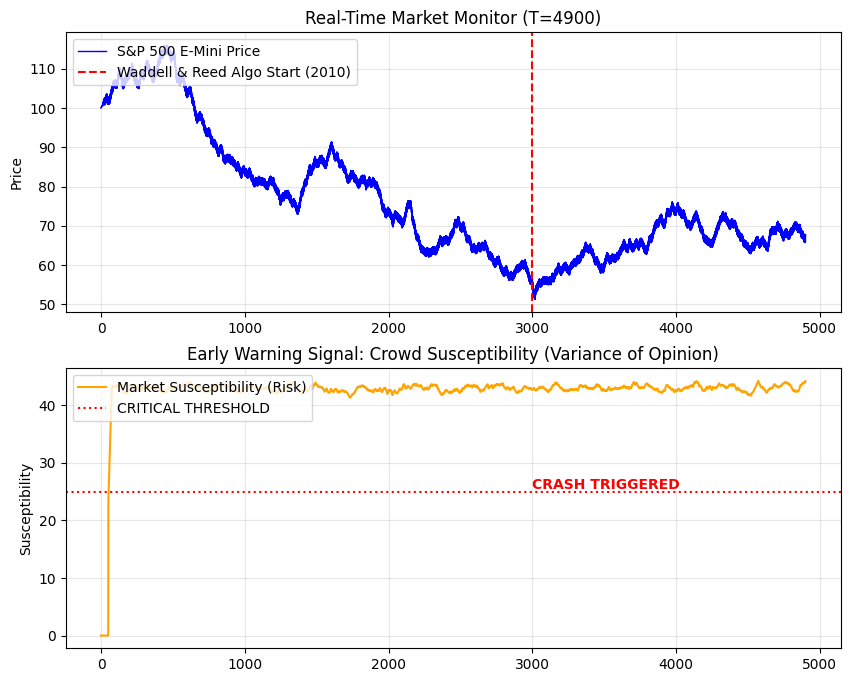

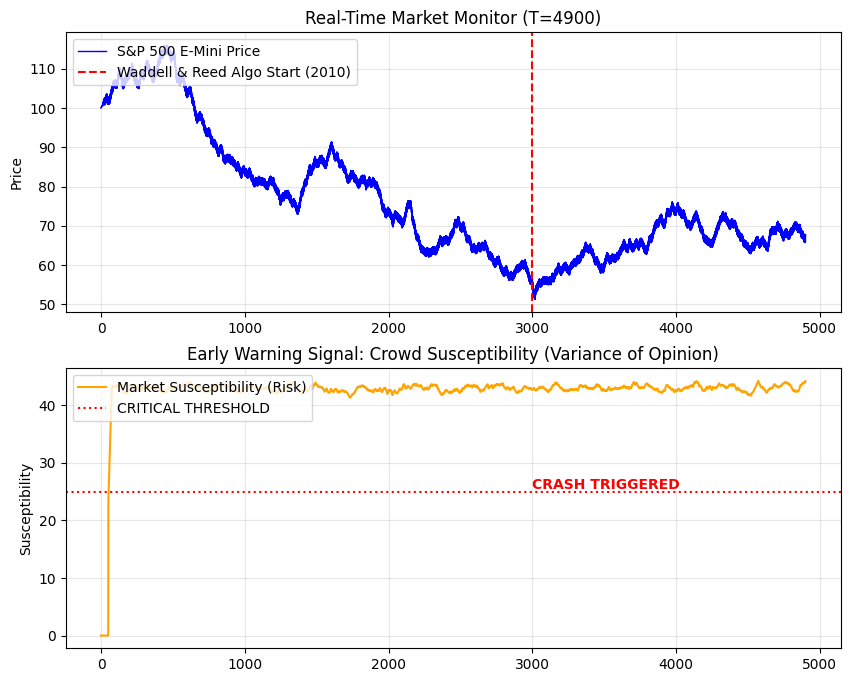

In [46]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
plt.ion()

for t in range(5000):

    if CRASH_TRIGGER_TIME <= t < CRASH_TRIGGER_TIME + 20:
        current_price -= 0.5

    current_agents, current_price, current_fund, sent = market_step(
        current_agents, current_price, current_fund, prev_price
    )
    prev_price = current_price

    if t > 50:

        recent_sent = sentiment_history[-50:]
        susceptibility = np.var(recent_sent) * 100
    else:
        susceptibility = 0

    price_history.append(current_price)
    sentiment_history.append(sent)
    susceptibility_history.append(susceptibility)

    if t % 100 == 0:
        clear_output(wait=True)


        ax1.clear()
        ax1.plot(price_history, color='blue', linewidth=1, label='S&P 500 E-Mini Price')

        ax1.axvline(x=CRASH_TRIGGER_TIME, color='red', linestyle='--', label='Waddell & Reed Algo Start (2010)')
        ax1.set_title(f"Real-Time Market Monitor (T={t})")
        ax1.set_ylabel("Price")
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)

        ax2.clear()
        ax2.plot(susceptibility_history, color='orange', linewidth=1.5, label='Market Susceptibility (Risk)')
        ax2.axhline(y=WARNING_THRESHOLD*100, color='red', linestyle=':', label='CRITICAL THRESHOLD')

        if t > CRASH_TRIGGER_TIME:
             ax2.text(CRASH_TRIGGER_TIME, (WARNING_THRESHOLD*100) + 0.5, "CRASH TRIGGERED", color='red', fontweight='bold')

        ax2.set_title("Early Warning Signal: Crowd Susceptibility (Variance of Opinion)")
        ax2.set_ylabel("Susceptibility")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        display(fig)